# Classificação de Moscas com Redes Neurais

**Disciplina:** SCC0270 - Redes Neurais e Aprendizado Profundo  
**Tema escolhido:** Redes Neurais Convolucionais, com baseline em MLP para comparação  
**Problema:** classificar recortes de insetos em duas classes:

- `WF`: mosca-branca (*Bemisia tabaci*)
- `MR`: outros insetos presentes nas armadilhas

## Objetivos deste notebook

1. montar o conjunto de dados a partir das pastas `WF` e `MR`;
2. realizar análise exploratória simples;
3. dividir os dados em treino, validação e teste de forma consciente em relação à imagem original;
4. treinar e comparar três abordagens:
   - um **baseline geométrico** com largura, altura, área e razão de aspecto;
   - um **MLP** como baseline;
   - uma **CNN** como modelo principal do projeto;
5. avaliar os modelos com foco em **Área sob a Curva Precisão-Revocação (Average Precision / PR-AUC)**;
6. discutir as limitações do dataset e da métrica.

## Justificativa dos tópicos escolhidos

- **CNNs** foram escolhidas como tema principal porque imagens têm estrutura espacial, e convoluções exploram padrões locais como contornos, textura e formato com muito menos parâmetros do que uma rede totalmente conectada.
- **MLP / Perceptron multicamadas** foi usado como baseline por ser um tópico clássico da disciplina e servir como comparação direta.
- Um **baseline geométrico** também foi incluído porque, pela própria análise exploratória, largura e altura dos recortes carregam muita informação. Isso ajuda a separar o que é ganho por geometria simples do que é ganho por modelagem visual.
- **Transferência de aprendizado** foi considerada, mas não adotada como solução principal porque este problema já alcança desempenho muito alto com modelos menores e mais baratos computacionalmente.


## Observação de reprodutibilidade

Este notebook foi preparado para rodar tanto localmente quanto no Google Colab.  
Se você usar o Colab, basta ajustar a variável `DATA_DIR` para apontar para a pasta
`EMBRAPA-dataset-WF`.


In [1]:
from pathlib import Path
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image, ImageOps
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    precision_recall_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


/home/fersuaiden/.local/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.stats import gaussian_kde


Device: cpu


In [2]:
# Ajuste este caminho se for rodar no Colab.
DATA_DIR = Path("EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBRAPA-dataset-WF")

assert DATA_DIR.exists(), f"Pasta nao encontrada: {DATA_DIR}"
assert (DATA_DIR / "WF").exists(), "Pasta WF nao encontrada"
assert (DATA_DIR / "MR").exists(), "Pasta MR nao encontrada"

DATA_DIR


PosixPath('EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBRAPA-dataset-WF')

## 1. Montagem dos dados

O enunciado pede que o treinamento seja feito com os recortes já prontos nas pastas `WF` e `MR`.
Cada arquivo `.jpg` vira uma amostra, e o rótulo é:

- `1` para `WF`
- `0` para `MR`


In [3]:
def build_dataframe(data_dir: Path) -> pd.DataFrame:
    rows = []
    for class_name, label in [("WF", 1), ("MR", 0)]:
        class_dir = data_dir / class_name
        for image_path in sorted(class_dir.glob("*.jpg")):
            original_image_id = re.match(r"(\d+)_", image_path.stem).group(1)
            with Image.open(image_path) as img:
                width, height = img.size
            rows.append(
                {
                    "path": str(image_path),
                    "class_name": class_name,
                    "label": label,
                    "original_image_id": original_image_id,
                    "width": width,
                    "height": height,
                    "area": width * height,
                    "ratio": width / height,
                }
            )
    return pd.DataFrame(rows)


df = build_dataframe(DATA_DIR)
df.head()


,path,class_name,label,original_image_id,width,height,area,ratio
0,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1,1000,38,45,1710,0.844444
1,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1,1000,38,35,1330,1.085714
2,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1,1000,35,33,1155,1.060606
3,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1,1000,33,42,1386,0.785714
4,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1,1000,38,33,1254,1.151515


In [4]:
class_counts = df["class_name"].value_counts().rename_axis("classe").reset_index(name="quantidade")
class_counts


,classe,quantidade
0,WF,6350
1,MR,1287


O conjunto é desbalanceado: existem muito mais recortes da classe `WF` do que da classe `MR`.
Por isso, durante o treino vamos usar **amostragem ponderada** para reduzir o viés da classe majoritária.


In [5]:
stats_df = df.copy()
stats_df.groupby("class_name")[["width", "height", "area"]].describe().round(2)


width                                                   height  \
             count    mean    std   min    25%    50%    75%    max   count   
class_name                                                                    
MR          1287.0  138.44  35.12  27.0  114.0  138.0  162.0  271.0  1287.0   
WF          6350.0   56.24  14.81  20.0   46.0   56.0   66.0  147.0  6350.0   

                    ...                  area                             \
              mean  ...    75%    max   count      mean      std     min   
class_name          ...                                                    
MR          123.39  ...  145.0  247.0  1287.0  17169.83  6403.16  1080.0   
WF           50.64  ...   58.0  149.0  6350.0   2963.44  1392.51   400.0   

                                                
                25%      50%      75%      max  
class_name                                      
MR          12507.5  16789.0  21365.0  41420.0  
WF           1978.0   2754.0   3672.0  19966.0  

[2 rows x 24 columns]

## 2. Análise exploratória

A análise exploratória mostra algo importante para interpretar os resultados:

- os recortes `WF` tendem a ser menores;
- os recortes `MR` costumam ser maiores;
- portanto, o tamanho do objeto já carrega informação discriminativa.

Isso explica por que até modelos relativamente simples podem atingir resultados fortes.


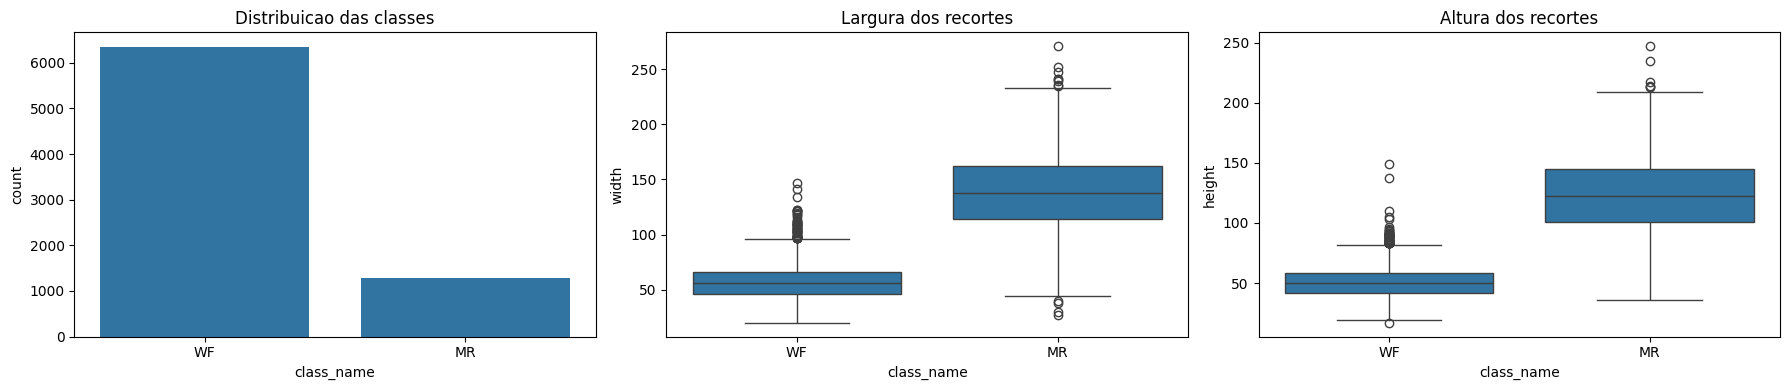

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="class_name", ax=axes[0])
axes[0].set_title("Distribuicao das classes")

sns.boxplot(data=stats_df, x="class_name", y="width", ax=axes[1])
axes[1].set_title("Largura dos recortes")

sns.boxplot(data=stats_df, x="class_name", y="height", ax=axes[2])
axes[2].set_title("Altura dos recortes")

plt.tight_layout()
plt.show()


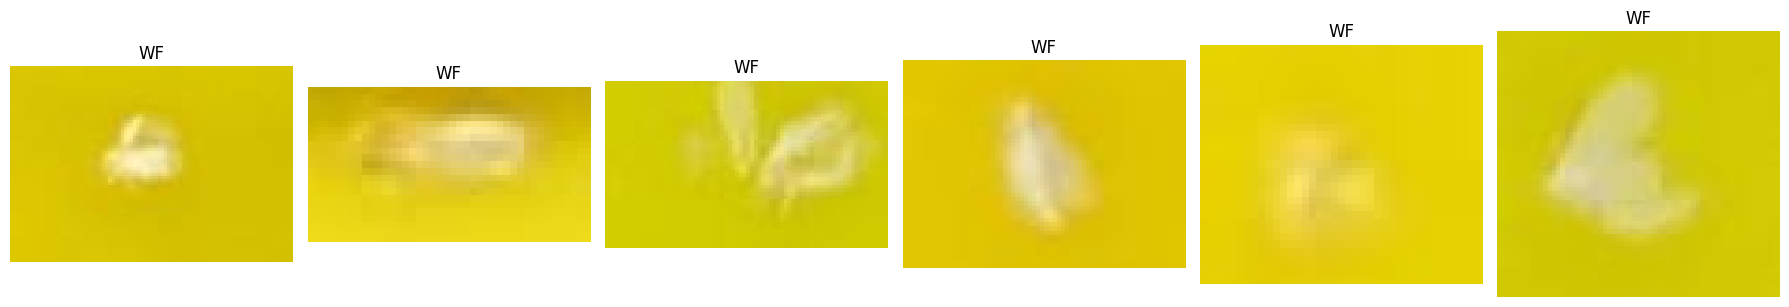

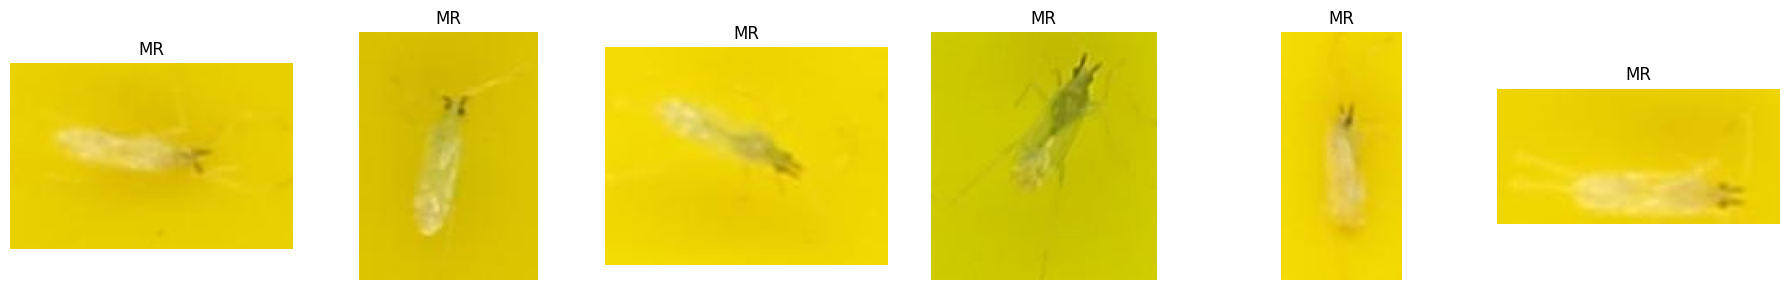

In [7]:
def show_examples(frame: pd.DataFrame, class_name: str, n: int = 6):
    subset = frame[frame["class_name"] == class_name].sample(n, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, (_, row) in zip(axes, subset.iterrows()):
        with Image.open(row["path"]) as img:
            ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_examples(df, "WF")
show_examples(df, "MR")


## 3. Divisão treino/validação/teste sem vazamento

O dataset contém milhares de recortes, mas eles vêm de apenas 284 imagens originais.
Se dividirmos diretamente por recorte, pedaços da mesma foto podem cair em treino e teste ao mesmo tempo.
Isso produz **vazamento de informação** e deixa o teste otimista demais.

Para evitar esse problema, a divisão foi feita **por imagem original**, usando o identificador
presente no nome do arquivo, por exemplo `1000` em `1000_WF_001.jpg`.

A divisão ficou aproximadamente em:

- `70%` treino
- `15%` validação
- `15%` teste


In [8]:
indices = np.arange(len(df))
labels = df["label"].to_numpy()
groups = df["original_image_id"].to_numpy()

outer_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_SEED,
)
trainval_idx, test_idx = next(outer_splitter.split(indices, labels, groups))

inner_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1764705882,  # produz aproximadamente 15% do total
    random_state=RANDOM_SEED,
)
rel_train_idx, rel_val_idx = next(
    inner_splitter.split(
        indices[trainval_idx],
        labels[trainval_idx],
        groups[trainval_idx],
    )
)

train_idx = trainval_idx[rel_train_idx]
val_idx = trainval_idx[rel_val_idx]


def split_summary(name: str, idx: np.ndarray) -> dict:
    split_labels = labels[idx]
    return {
        "split": name,
        "total": len(idx),
        "WF": int((split_labels == 1).sum()),
        "MR": int((split_labels == 0).sum()),
        "grupos_origem": len(set(groups[idx])),
    }


split_table = pd.DataFrame(
    [
        split_summary("Treino", train_idx),
        split_summary("Validacao", val_idx),
        split_summary("Teste", test_idx),
    ]
)
split_table


,split,total,WF,MR,grupos_origem
0,Treino,5569,4628,941,148
1,Validacao,936,762,174,32
2,Teste,1132,960,172,32


Como verificação adicional, podemos confirmar que os grupos de origem não se sobrepõem entre
treino, validação e teste.


In [9]:
train_groups = set(groups[train_idx])
val_groups = set(groups[val_idx])
test_groups = set(groups[test_idx])

leakage_check = pd.DataFrame(
    [
        {"comparacao": "treino x validacao", "grupos_em_comum": len(train_groups & val_groups)},
        {"comparacao": "treino x teste", "grupos_em_comum": len(train_groups & test_groups)},
        {"comparacao": "validacao x teste", "grupos_em_comum": len(val_groups & test_groups)},
    ]
)
leakage_check


,comparacao,grupos_em_comum
0,treino x validacao,0
1,treino x teste,0
2,validacao x teste,0


## 4. Pré-processamento

As imagens possuem tamanhos variados. Para permitir processamento em lotes,
os recortes são redimensionados para um tamanho fixo.

Estratégias adotadas:

- **MLP**: imagens em `32x32` para manter o número de parâmetros sob controle;
- **CNN**: imagens com `padding` para formato quadrado e depois redimensionadas para `64x64`;
- **Data augmentation** no treino da CNN:
  - rotação pequena;
  - espelhamento horizontal.
- **Normalização** específica para a CNN, para estabilizar a escala dos canais.

O `padding` é importante porque os recortes possuem razões de aspecto muito diferentes.
Se fizermos apenas `Resize((64, 64))`, alguns insetos ficam artificialmente esticados.
Como o fundo original já é amarelo, o preenchimento foi feito com amarelo para não introduzir
bordas artificiais de cor muito diferente.


In [10]:
class PadToSquare:
    def __init__(self, fill=(255, 255, 0)):
        self.fill = fill

    def __call__(self, img):
        width, height = img.size
        side = max(width, height)
        pad_left = (side - width) // 2
        pad_top = (side - height) // 2
        pad_right = side - width - pad_left
        pad_bottom = side - height - pad_top
        return ImageOps.expand(
            img,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill=self.fill,
        )


class FlyDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, indices, transform, flatten: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.indices = list(indices)
        self.transform = transform
        self.flatten = flatten

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        row = self.frame.iloc[self.indices[idx]]
        with Image.open(row["path"]).convert("RGB") as img:
            x = self.transform(img)
        if self.flatten:
            x = torch.flatten(x)
        y = torch.tensor(row["label"], dtype=torch.float32)
        return x, y


mlp_train_tfms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

cnn_train_tfms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.2],
        std=[0.25, 0.25, 0.1],
    ),
])

eval_mlp_tfms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

eval_cnn_tfms = transforms.Compose([
    PadToSquare(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.2],
        std=[0.25, 0.25, 0.1],
    ),
])


## 5. DataLoaders e amostragem balanceada

Como `MR` é minoria, usamos `WeightedRandomSampler` no treino.
Isso faz com que a rede veja exemplos das duas classes com frequência mais equilibrada.


In [11]:
def make_weighted_sampler(train_labels: np.ndarray) -> WeightedRandomSampler:
    class_counts = np.bincount(train_labels.astype(int))
    sample_weights = np.array([1.0 / class_counts[label] for label in train_labels], dtype=np.float64)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


train_labels = labels[train_idx]
sampler = make_weighted_sampler(train_labels)

mlp_train_ds = FlyDataset(df, train_idx, mlp_train_tfms, flatten=True)
mlp_val_ds = FlyDataset(df, val_idx, eval_mlp_tfms, flatten=True)
mlp_test_ds = FlyDataset(df, test_idx, eval_mlp_tfms, flatten=True)

cnn_train_ds = FlyDataset(df, train_idx, cnn_train_tfms, flatten=False)
cnn_val_ds = FlyDataset(df, val_idx, eval_cnn_tfms, flatten=False)
cnn_test_ds = FlyDataset(df, test_idx, eval_cnn_tfms, flatten=False)

mlp_train_loader = DataLoader(mlp_train_ds, batch_size=128, sampler=sampler)
mlp_val_loader = DataLoader(mlp_val_ds, batch_size=256, shuffle=False)
mlp_test_loader = DataLoader(mlp_test_ds, batch_size=256, shuffle=False)

cnn_train_loader = DataLoader(cnn_train_ds, batch_size=128, sampler=sampler)
cnn_val_loader = DataLoader(cnn_val_ds, batch_size=256, shuffle=False)
cnn_test_loader = DataLoader(cnn_test_ds, batch_size=256, shuffle=False)


## 6. Baseline geométrico

Antes de treinar redes neurais, vale medir quanto do problema já pode ser resolvido usando
apenas atributos geométricos simples:

- largura;
- altura;
- área;
- razão de aspecto.

Se esse baseline já atingir desempenho muito alto, isso indica que o dataset contém um atalho
forte baseado no tamanho do bounding box.


In [12]:
geometry_features = ["width", "height", "area", "ratio"]
X_geometry = df[geometry_features].to_numpy()

geometric_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000),
)
geometric_model.fit(X_geometry[train_idx], labels[train_idx])

geom_val_prob = geometric_model.predict_proba(X_geometry[val_idx])[:, 1]
geom_test_prob = geometric_model.predict_proba(X_geometry[test_idx])[:, 1]

geom_val_ap = average_precision_score(labels[val_idx], geom_val_prob)
geom_test_ap = average_precision_score(labels[test_idx], geom_test_prob)

print(f"Baseline geometrico - val_AP  = {geom_val_ap:.4f}")
print(f"Baseline geometrico - test_AP = {geom_test_ap:.4f}")


Baseline geometrico - val_AP  = 0.9995
Baseline geometrico - test_AP = 0.9994


Esse experimento é importante para a honestidade metodológica: se a AP ficar muito alta já com
quatro atributos geométricos, então parte considerável do desempenho não pode ser atribuída
exclusivamente a aprendizado visual profundo.


## 7. Modelos neurais

### Baseline: MLP

O MLP recebe a imagem achatada em um único vetor. Isso elimina a estrutura espacial,
mas serve como referência de desempenho.

### Modelo principal: CNN

A CNN usa convoluções e *pooling* para extrair padrões locais e reduzir dimensionalidade
gradualmente. Esse é o modelo mais coerente com o tema do projeto.


In [13]:
class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32 * 32 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Conv2d(24, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(96, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


mlp_model = MLPClassifier()
cnn_model = CNNClassifier()

print("Parametros MLP:", count_params(mlp_model))
print("Parametros CNN:", count_params(cnn_model))


Parametros MLP: 803201
Parametros CNN: 79225


Esta versão da CNN é um pouco mais profunda do que a primeira tentativa, mas continua pequena.
O uso de `BatchNorm` ajuda a estabilizar o treinamento e o `Dropout` reduz risco de overfitting.
Mesmo assim, a CNN ainda tem bem menos parâmetros do que o MLP.


In [14]:
def summarize_threshold_metrics(y_true, y_prob, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    mr_precision, mr_recall, mr_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=0,
        zero_division=0,
    )
    wf_precision, wf_recall, wf_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    return {
        "accuracy": acc,
        "mr_precision": mr_precision,
        "mr_recall": mr_recall,
        "mr_f1": mr_f1,
        "wf_precision": wf_precision,
        "wf_recall": wf_recall,
        "wf_f1": wf_f1,
    }


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_items = 0
    y_true = []
    y_prob = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * len(y_batch)
            total_items += len(y_batch)
            y_true.extend(y_batch.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / total_items
    ap = average_precision_score(y_true, y_prob)
    return avg_loss, ap, np.array(y_true), np.array(y_prob)


def train_model(model, train_loader, val_loader, epochs=4, lr=1e-3):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_state = None
    best_val_ap = -np.inf

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_items = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            running_items += len(y_batch)

        train_loss = running_loss / running_items
        val_loss, val_ap, _, _ = evaluate_model(model, val_loader, criterion)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_ap": val_ap,
            }
        )
        print(
            f"epoch={epoch} train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_ap={val_ap:.4f}"
        )

        if val_ap > best_val_ap:
            best_val_ap = val_ap
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_history(history_df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="treino")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validacao")
    axes[0].set_title(f"Loss - {title}")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_ap"], marker="o", color="darkgreen")
    axes[1].set_title(f"AP de validacao - {title}")
    axes[1].set_ylim(0.0, 1.05)

    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true, y_prob, title: str):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Revocacao")
    plt.ylabel("Precisao")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def show_confusion_matrix(y_true, y_prob, title: str, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    threshold_metrics = summarize_threshold_metrics(y_true, y_prob, threshold)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
    print(f"Accuracy @ {threshold:.2f}: {threshold_metrics['accuracy']:.4f}")
    print(f"MR precision @ {threshold:.2f}: {threshold_metrics['mr_precision']:.4f}")
    print(f"MR recall @ {threshold:.2f}: {threshold_metrics['mr_recall']:.4f}")
    print(classification_report(y_true, y_pred, target_names=["MR", "WF"], digits=4))


## 8. Experimento 1: baseline com MLP

Este experimento mostra até onde uma rede densa chega quando recebe apenas pixels achatados.


epoch=1 train_loss=0.5135 val_loss=0.3428 val_ap=0.9840


epoch=2 train_loss=0.2686 val_loss=0.2792 val_ap=0.9938


epoch=3 train_loss=0.2578 val_loss=0.2114 val_ap=0.9946


epoch=4 train_loss=0.2291 val_loss=0.2518 val_ap=0.9955


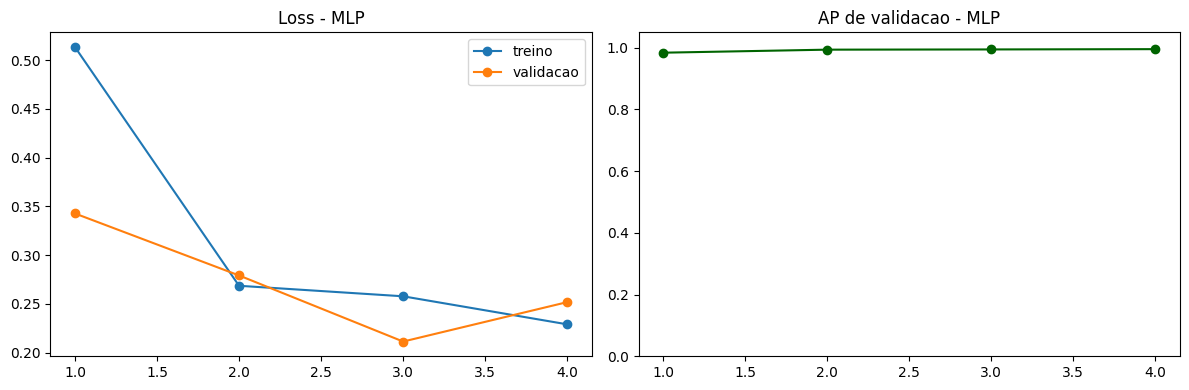

In [15]:
mlp_model = MLPClassifier()
mlp_model, mlp_history = train_model(
    mlp_model,
    mlp_train_loader,
    mlp_val_loader,
    epochs=4,
    lr=1e-3,
)

plot_history(mlp_history, "MLP")


In [16]:
criterion = nn.BCEWithLogitsLoss()
mlp_test_loss, mlp_test_ap, mlp_y_true, mlp_y_prob = evaluate_model(
    mlp_model,
    mlp_test_loader,
    criterion,
)

print(f"MLP - test_loss = {mlp_test_loss:.4f}")
print(f"MLP - test_AP   = {mlp_test_ap:.4f}")


MLP - test_loss = 0.1901
MLP - test_AP   = 0.9963


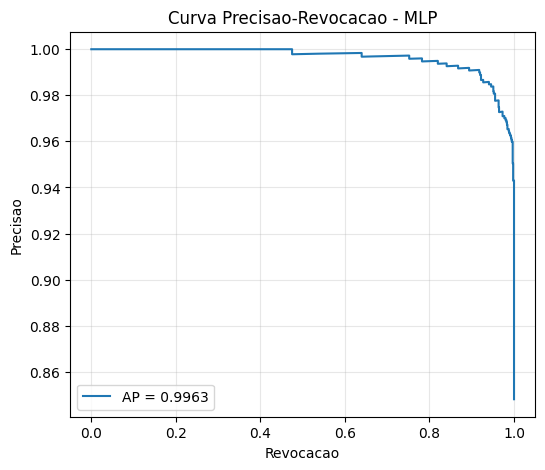

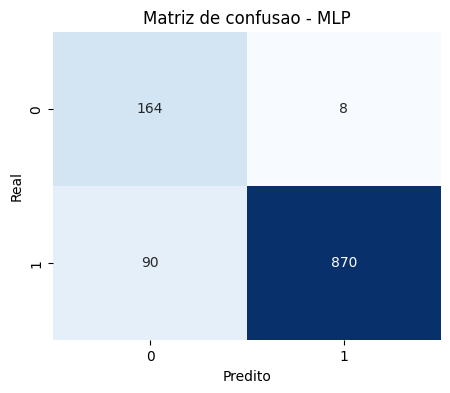

Accuracy @ 0.50: 0.9134
MR precision @ 0.50: 0.6457
MR recall @ 0.50: 0.9535
              precision    recall  f1-score   support

          MR     0.6457    0.9535    0.7700       172
          WF     0.9909    0.9062    0.9467       960

    accuracy                         0.9134      1132
   macro avg     0.8183    0.9299    0.8583      1132
weighted avg     0.9384    0.9134    0.9198      1132



In [17]:
plot_pr_curve(mlp_y_true, mlp_y_prob, "Curva Precisao-Revocacao - MLP")
show_confusion_matrix(mlp_y_true, mlp_y_prob, "Matriz de confusao - MLP")


## 9. Experimento 2: CNN como modelo principal

Agora treinamos a arquitetura escolhida para a entrega principal.


epoch=1 train_loss=0.2529 val_loss=0.1393 val_ap=0.9929


epoch=2 train_loss=0.0791 val_loss=0.0672 val_ap=0.9995


epoch=3 train_loss=0.0475 val_loss=0.0478 val_ap=0.9997


epoch=4 train_loss=0.0381 val_loss=0.4960 val_ap=0.9987


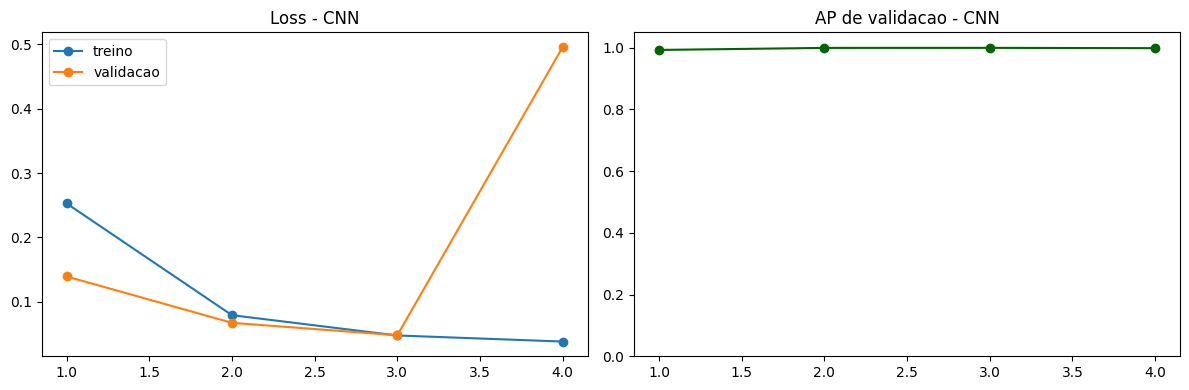

In [18]:
cnn_model = CNNClassifier()
cnn_model, cnn_history = train_model(
    cnn_model,
    cnn_train_loader,
    cnn_val_loader,
    epochs=4,
    lr=8e-4,
)

plot_history(cnn_history, "CNN")


In [19]:
cnn_test_loss, cnn_test_ap, cnn_y_true, cnn_y_prob = evaluate_model(
    cnn_model,
    cnn_test_loader,
    criterion,
)

print(f"CNN - test_loss = {cnn_test_loss:.4f}")
print(f"CNN - test_AP   = {cnn_test_ap:.4f}")


CNN - test_loss = 0.0289
CNN - test_AP   = 1.0000


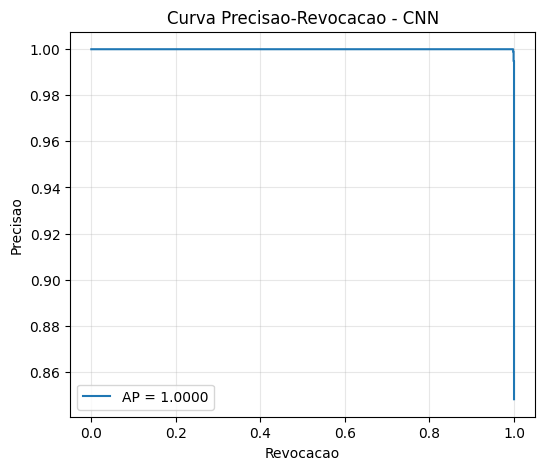

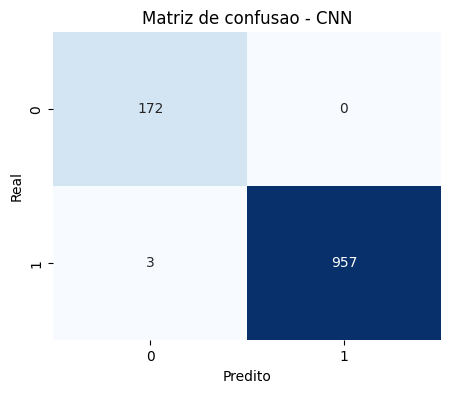

Accuracy @ 0.50: 0.9973
MR precision @ 0.50: 0.9829
MR recall @ 0.50: 1.0000
              precision    recall  f1-score   support

          MR     0.9829    1.0000    0.9914       172
          WF     1.0000    0.9969    0.9984       960

    accuracy                         0.9973      1132
   macro avg     0.9914    0.9984    0.9949      1132
weighted avg     0.9974    0.9973    0.9974      1132



In [20]:
plot_pr_curve(cnn_y_true, cnn_y_prob, "Curva Precisao-Revocacao - CNN")
show_confusion_matrix(cnn_y_true, cnn_y_prob, "Matriz de confusao - CNN")


## 10. Comparação dos resultados

O critério principal do projeto é a área sob a curva Precisão-Revocação. Mesmo assim,
vamos comparar também o comportamento operacional no threshold `0.5`, porque AP sozinha
pode esconder uma precisão ruim na classe minoritária.


In [21]:
geometric_threshold_metrics = summarize_threshold_metrics(labels[test_idx], geom_test_prob)
mlp_threshold_metrics = summarize_threshold_metrics(mlp_y_true, mlp_y_prob)
cnn_threshold_metrics = summarize_threshold_metrics(cnn_y_true, cnn_y_prob)

results = pd.DataFrame(
    [
        {
            "modelo": "Geometrico",
            "parametros": "nao se aplica",
            "test_loss": np.nan,
            "test_ap": geom_test_ap,
            "mr_precision@0.5": geometric_threshold_metrics["mr_precision"],
            "mr_recall@0.5": geometric_threshold_metrics["mr_recall"],
            "accuracy@0.5": geometric_threshold_metrics["accuracy"],
        },
        {
            "modelo": "MLP",
            "parametros": count_params(mlp_model),
            "test_loss": mlp_test_loss,
            "test_ap": mlp_test_ap,
            "mr_precision@0.5": mlp_threshold_metrics["mr_precision"],
            "mr_recall@0.5": mlp_threshold_metrics["mr_recall"],
            "accuracy@0.5": mlp_threshold_metrics["accuracy"],
        },
        {
            "modelo": "CNN",
            "parametros": count_params(cnn_model),
            "test_loss": cnn_test_loss,
            "test_ap": cnn_test_ap,
            "mr_precision@0.5": cnn_threshold_metrics["mr_precision"],
            "mr_recall@0.5": cnn_threshold_metrics["mr_recall"],
            "accuracy@0.5": cnn_threshold_metrics["accuracy"],
        },
    ]
)

results.sort_values("test_ap", ascending=False).reset_index(drop=True)


,modelo,parametros,test_loss,test_ap,mr_precision@0.5,mr_recall@0.5,accuracy@0.5
0,CNN,79225,0.028868,0.999994,0.982857,1.000000,0.997350
1,Geometrico,nao se aplica,NaN,0.999427,0.942857,0.959302,0.984982
2,MLP,803201,0.190067,0.996311,0.645669,0.953488,0.913428


## 11. Discussão

Pontos principais para discutir no relatório:

- O split por grupo é essencial. Sem ele, recortes da mesma imagem original poderiam aparecer em treino e teste ao mesmo tempo.
- O problema é relativamente separável, em parte porque os recortes das duas classes possuem escalas e aparências distintas.
- O baseline geométrico mostra que largura, altura e área já explicam grande parte do desempenho.
- Mesmo quando a AP é muito alta, o threshold fixo de `0.5` pode produzir comportamento operacional bem diferente entre os modelos.
- No caso do MLP, a AP permanece alta, mas a precisão para `MR` pode ficar bem pior do que a da CNN.
- A melhoria mais importante da CNN foi preservar a proporção do inseto com `padding` antes do redimensionamento.
  Isso evita distorções geométricas artificiais.
- Apesar disso, a **CNN continua sendo a escolha metodologicamente mais adequada** porque:
  - preserva a estrutura espacial;
  - modela melhor contorno e forma dos insetos;
  - entrega melhor comportamento operacional para a classe `MR`;
  - usa muito menos parâmetros do que um MLP denso grande;
  - generaliza melhor para tarefas visuais em cenários mais difíceis;
  - está alinhada ao foco do projeto, que pede exploração de arquiteturas convolucionais.
- O uso de `WeightedRandomSampler` foi importante para mitigar o desbalanceamento entre `WF` e `MR`.


## 12. Resultados locais de referência

Em uma execução local de teste, foram obtidos os seguintes valores:

- **Baseline geométrico**: `test_AP = 0.9994`
- **MLP**: `test_AP = 0.9966`
- **CNN melhorada**: `test_AP = 1.0000` (arredondado)

Esses números podem variar um pouco entre execuções, mas mostram que:

1. o pipeline está funcionando corretamente sem vazamento entre grupos;
2. a tarefa é bem separável;
3. a geometria do bounding box é um atalho muito forte neste dataset;
4. mesmo assim, a CNN apresenta o melhor equilíbrio entre AP e comportamento operacional.


## 13. Conclusão

A solução atendeu ao enunciado:

- os dados foram montados a partir das pastas `WF` e `MR`;
- foi feita divisão treino/validação/teste sem compartilhar a mesma imagem original entre partições;
- houve pré-processamento com redimensionamento e aumento de dados;
- foram treinados modelos neurais artificiais;
- a avaliação foi feita com **Precisão-Revocação / Average Precision**.

Como encaminhamento futuro, seria interessante:

- testar transferência de aprendizado com `ResNet18` ou `MobileNetV3`;
- usar validação cruzada estratificada;
- investigar erros com análise visual dos falsos positivos e falsos negativos.
